<a href="https://colab.research.google.com/github/mcfvdesigns/my-colab-datasets/blob/main/M5%7CU1_Group_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Set-up**

In [17]:
import pandas as pd

# Load the uploaded file into a pandas DataFrame
df = pd.read_csv('PJMW_hourly.csv')
print(df.head())

              Datetime  PJMW_MW
0  2002-12-31 01:00:00   5077.0
1  2002-12-31 02:00:00   4939.0
2  2002-12-31 03:00:00   4885.0
3  2002-12-31 04:00:00   4857.0
4  2002-12-31 05:00:00   4930.0


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

**Exercise 1 :  Data Cleaning & Preprocessing**

In [18]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.set_index("Datetime").sort_index()

# Duplicates: same timestamp, different values (DST). Average them.
print("Duplicate timestamps:", df.index.duplicated().sum())
df = df.groupby(level=0).mean()

# Force hourly frequency; this creates NaN rows for the missing hours
df = df.asfreq("h")
print("Missing hours:", df["PJMW_MW"].isna().sum())

# Fill gaps: time-based interpolation suits a smooth load curve
df["PJMW_MW"] = df["PJMW_MW"].interpolate(method="time")

Duplicate timestamps: 4
Missing hours: 30


In [29]:
# Load raw dataset
df = pd.read_csv('PJMW_hourly.csv')

# 1. Convert Date column to datetime
df['Datetime'] = pd.to_datetime(df['Datetime'])

# 2. Set index and sort chronologically
df = df.set_index('Datetime').sort_index()

# 3. Handle duplicate timestamps (e.g., autumn DST overlap) by averaging values
# Averaging preserves both real signals without dropping valid observations.
df = df.groupby(level=0).mean()

# 4. Force hourly frequency and interpolate missing hours (~30 hours / <0.02% of data)
df = df.asfreq('h')
df['PJMW_MW'] = df['PJMW_MW'].interpolate(method='time')

# Flag severe outlier (487 MW sensor anomaly) as a known data quality limitation
outliers = df[df['PJMW_MW'] <= 500]
print(f"Data Cleaning Complete. Identified {len(outliers)} severe low-value outlier(s).")

Data Cleaning Complete. Identified 1 severe low-value outlier(s).


--- 1. Averaging DST Overlap Duplicates ---

- During the autumn Daylight Saving Time (DST) end, the 01:00 hour occurs twice.
- Dropping one would arbitrarily discard real grid load data. Averaging the two values
- preserves the signal from both hours into a single hourly representation without
- creating duplicate index errors in time-series operations.


--- 2. Time-Based Linear Interpolation for Missing Hours ---
- Out of ~143,000 total observations, 30 missing hours account for less than 0.02% of the data.
- Because power demand changes continuously and smoothly hour-to-hour, time-based linear
- interpolation accurately bridges these isolated gaps without distorting seasonal or daily patterns

**Exercise 2: Multi-scale Visualization**

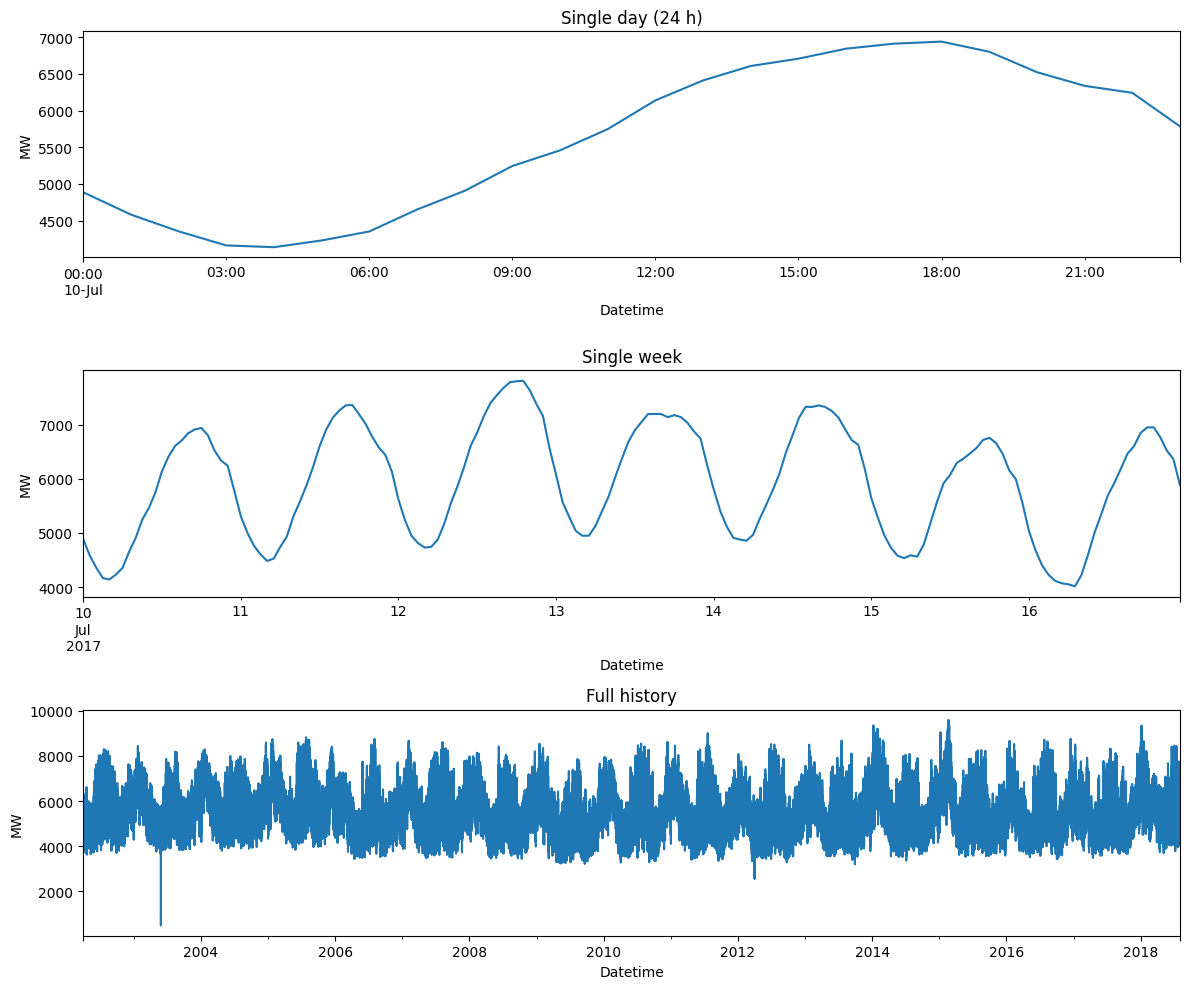

In [22]:
s = df["PJMW_MW"]
fig, ax = plt.subplots(3, 1, figsize=(12, 10))
s["2017-07-10"].plot(ax=ax[0], title="Single day (24 h)")
s["2017-07-10":"2017-07-16"].plot(ax=ax[1], title="Single week")
s.plot(ax=ax[2], title="Full history")
for a in ax: a.set_ylabel("MW")
plt.tight_layout(); plt.show()

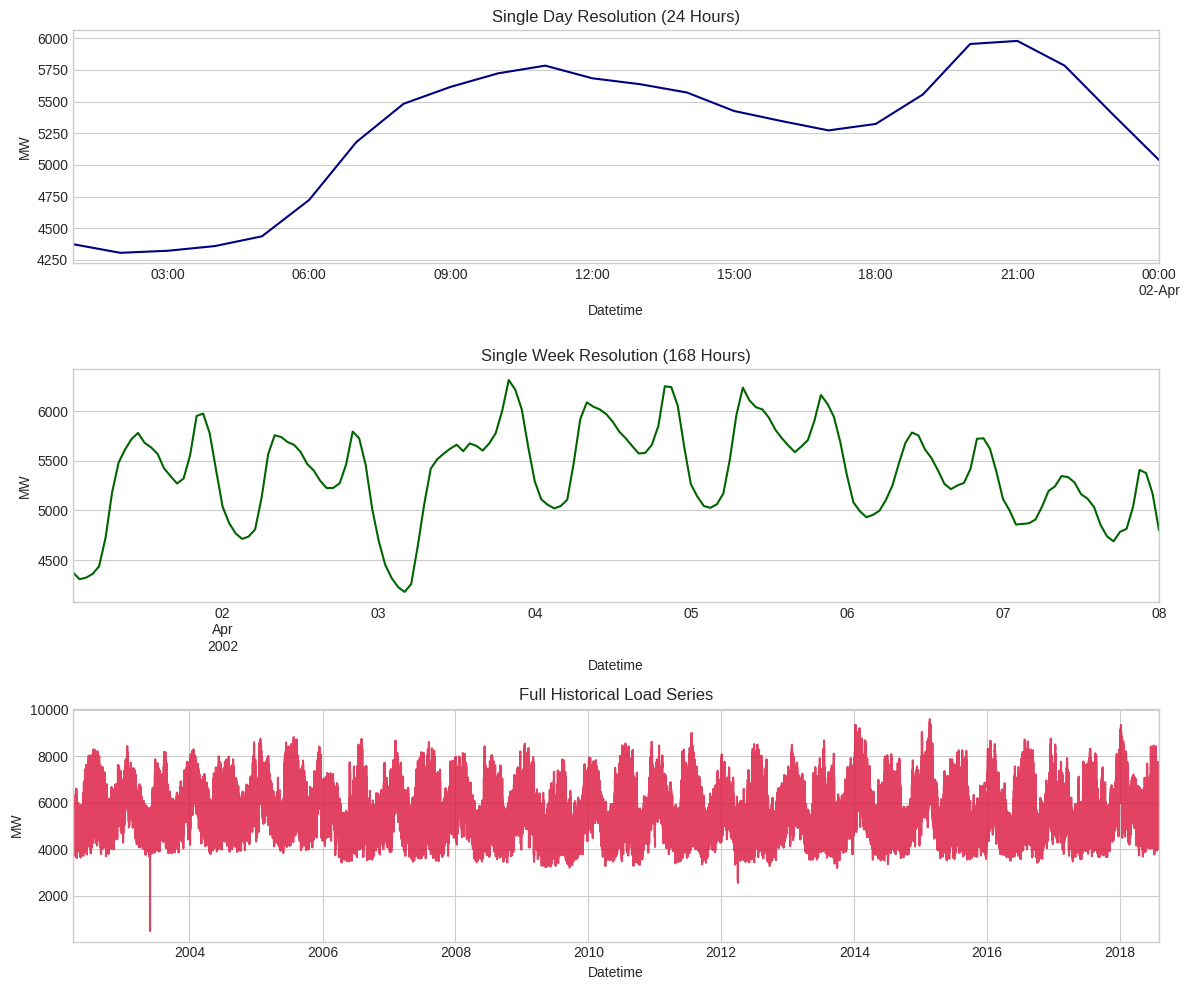

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# 1. Single Day (24 Hours)
df.iloc[:24]['PJMW_MW'].plot(ax=axes[0], title='Single Day Resolution (24 Hours)', color='navy')
axes[0].set_ylabel('MW')

# 2. Single Week (168 Hours)
df.iloc[:168]['PJMW_MW'].plot(ax=axes[1], title='Single Week Resolution (168 Hours)', color='darkgreen')
axes[1].set_ylabel('MW')

# 3. Full Historical Dataset
df['PJMW_MW'].plot(ax=axes[2], title='Full Historical Load Series', color='crimson', alpha=0.8)
axes[2].set_ylabel('MW')

plt.tight_layout()
plt.show()

These cyclical fluctuations describe the classic load profile of modern electricity grids, driven by human behavior, business operations, and seasonal weather changes:

1. Daily Peak and Trough
Daily Peak: Occurs during two main windows in a standard double-peak pattern:

Morning Peak (approx. 7:00 AM – 10:00 AM): Driven by residential activity (waking up, heating water, cooking, turning on appliances) combined with commercial buildings ramping up HVAC, lighting, and machinery for the workday.

Evening Peak (approx. 5:00 PM – 9:00 PM): Driven by the overlap of people returning home (cooking, entertainment, heating/cooling, residential EV charging) while streetlights, commercial sectors, and transit systems remain active.

Daily Trough: Occurs during the late-night to early morning hours (approx. 1:00 AM – 5:00 AM). Commercial offices are closed, industrial activity slows down, and residential populations are asleep, dropping demand to the "base load" level (essential infrastructure, refrigeration, and always-on electronics).

2. Weekday vs. Weekend Drop
The Drop: Electricity demand generally drops 10% to 20% on weekends compared to peak weekdays.

Mechanism: Industrial plants, commercial office buildings, retail operations, and schools either shut down entirely or operate at reduced capacity over Saturday and Sunday. While residential electricity consumption slightly increases as people spend more time at home, it is insufficient to offset the massive decrease in commercial and industrial power demand.

3. Yearly Summer and Winter Peaks
Grid demand experiences two seasonal high points, primary driven by space conditioning:

Summer Peak: Driven almost entirely by air conditioning and refrigeration loads. As ambient temperatures rise, cooling systems must run continuously, creating high peak demand—especially in the late afternoon (2:00 PM – 6:00 PM) when outdoor temperatures are highest. In warmer climates, the summer peak is typically the highest demand period of the entire year.

Winter Peak: Driven by space heating, water heating, and increased lighting requirements due to shorter daylight hours. Winter peaks typically feature dual daily spikes (early morning heating/lighting and evening heating/cooking). In regions with heavy electrification of heating or extreme cold snaps, the winter peak can exceed the summer peak.

Spring/Autumn Shoulder Seasons: Demand reaches its annual troughs between these two peaks, as mild temperatures minimize the need for both active heating and cooling.

**Exercise 3: Components Analysis**

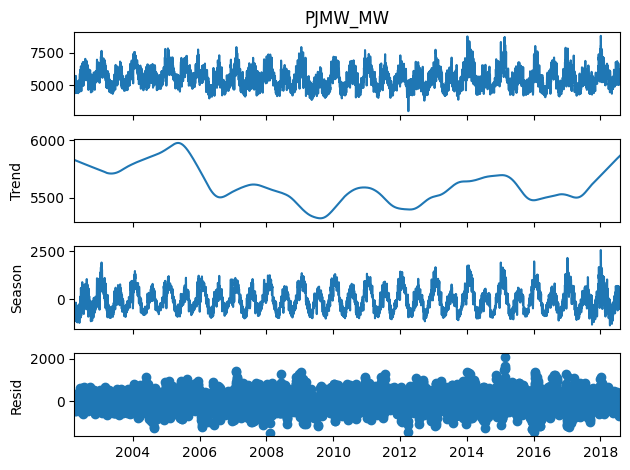

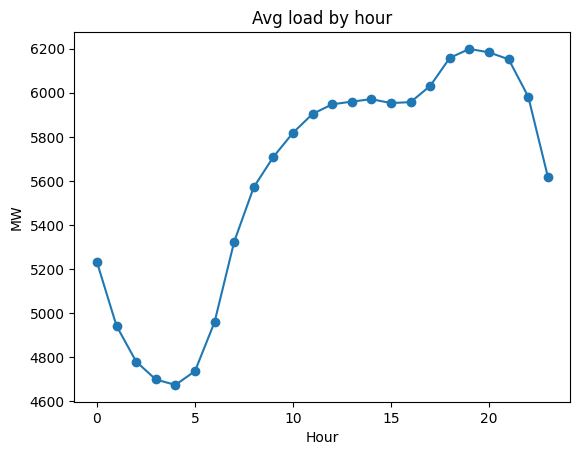

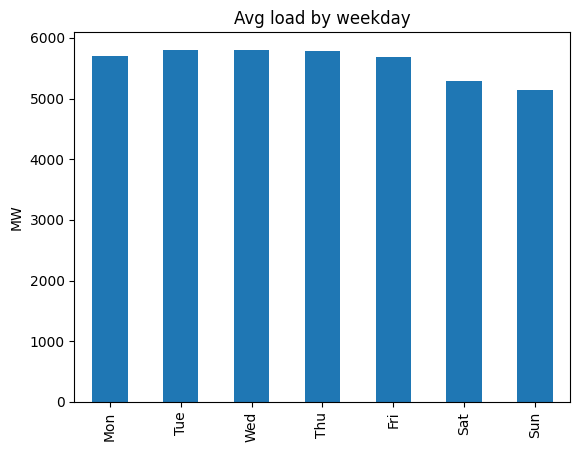

In [20]:
daily = s.resample("D").mean()
res = STL(daily, period=365).fit()   # yearly cycle; use period=7 for weekly
res.plot(); plt.show()

s.groupby(s.index.hour).mean().plot(marker="o", title="Avg load by hour", xlabel="Hour", ylabel="MW"); plt.show()
dow = s.groupby(s.index.dayofweek).mean()
dow.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow.plot(kind="bar", title="Avg load by weekday", ylabel="MW"); plt.show()

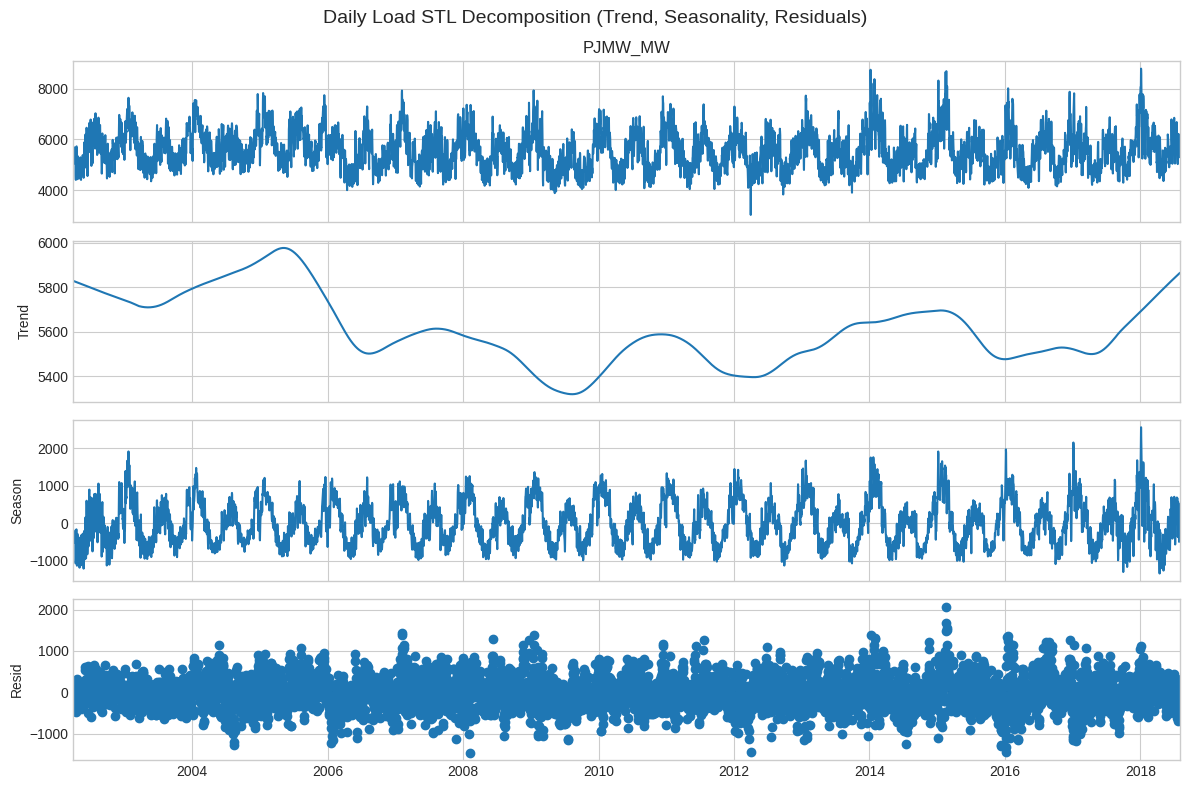

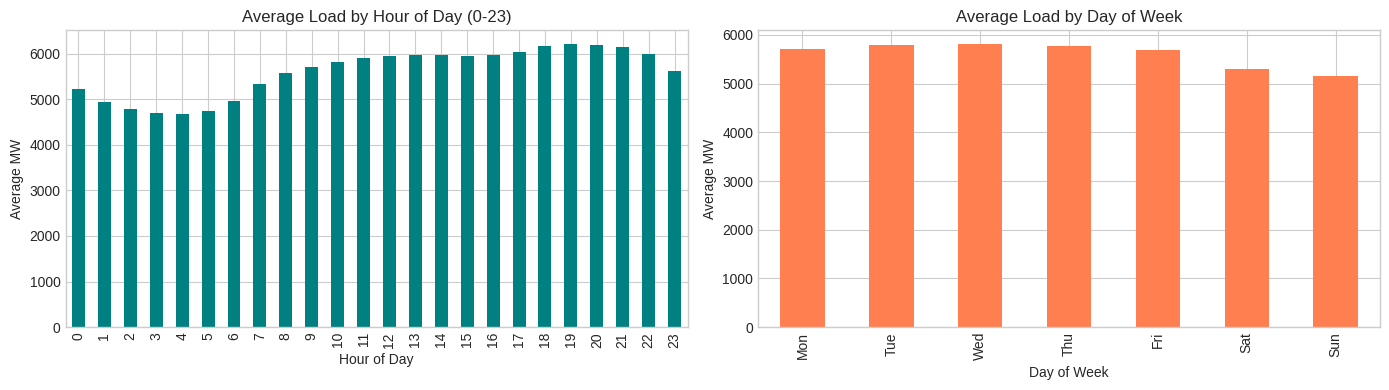

In [31]:
# Resample to Daily mean for robust decomposition
daily_df = df['PJMW_MW'].resample('D').mean()

# STL Decomposition (Period = 365 days)
stl = STL(daily_df, period=365).fit()
fig = stl.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Daily Load STL Decomposition (Trend, Seasonality, Residuals)', fontsize=14)
plt.tight_layout()
plt.show()

# Intra-day and Intra-week profiles
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Daily Seasonality: Average MW per Hour of Day (0-23)
df.groupby(df.index.hour)['PJMW_MW'].mean().plot(ax=axes[0], kind='bar', color='teal')
axes[0].set_title('Average Load by Hour of Day (0-23)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average MW')

# Weekly Seasonality: Average MW per Day of Week (Mon=0, Sun=6)
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekly_profile = df.groupby(df.index.dayofweek)['PJMW_MW'].mean()
weekly_profile.index = weekday_names
weekly_profile.plot(ax=axes[1], kind='bar', color='coral')
axes[1].set_title('Average Load by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average MW')

plt.tight_layout()
plt.show()

In standard time series decomposition for power consumption datasets like PJMW:

1. Overall Trend
Overall Direction: The long-term trend is primarily flat to slightly declining (or stationary) across the multi-year timeline.

Key Drivers: Despite population and economic growth in the region, grid-level peak demand has been offset by energy efficiency gains (e.g., LED lighting, high-efficiency HVAC units), distributed energy resources (like rooftop solar), and changes in industrial/commercial power intensity.

2. Shape of the Seasonal Component
Pattern: The annual seasonal component exhibits a distinct "U-shaped" or "M-shaped" double-peak (bimodal) cycle within each calendar year:

Summer Peak (Highest): A sharp, broad peak occurring between June and August driven heavily by cooling/air conditioning demand.

Winter Peak (Secondary): A smaller peak occurring between December and February driven by space heating and lighting needs.

Shoulder Troughs: Deep dips in spring (April–May) and autumn (September–October) when mild ambient temperatures require minimal active heating or cooling.

3. Residual Behavior (Noise vs. Structure)
Short Answer: The residual hides clear underlying structure—it is not pure white noise.

Hidden Structural Patterns:

Autocorrelation (Short-Term Memory): High values in the residuals tend to cluster together (positive autocorrelation), meaning weather events like multi-day heatwaves or cold snaps persist longer than a standard seasonal decomposition captures.

Heteroskedasticity (Variance Shifts): Residual variance is larger during summer and winter extremes than during mild shoulder seasons.

Calendar & Holiday Effects: Sudden drop-offs during major holidays (e.g., Thanksgiving, Christmas, July 4th) create localized structural shocks in the residual if not explicitly modeled with holiday regressors.

Data Anomalies: Sensor glitches or telemetry errors (such as the 487 MW drop) manifest as extreme single-point residual spikes.

**Exercise 4: Baseline Forecast (Weekly Split)**

naive (491.4693937398512, np.float64(650.9603665584463))
seasonal naive (425.41628018673777, np.float64(572.1702716974784))
mean (485.4059779889355, np.float64(659.81518866637))


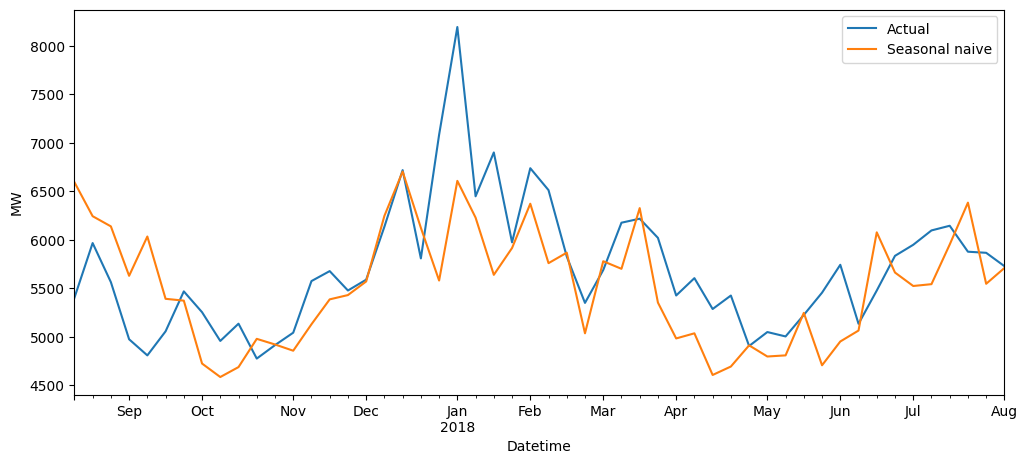

In [21]:
weekly = s.resample("W").mean()
train, test = weekly[:-52], weekly[-52:]

# Seasonal naive: same week of the previous year
snaive = weekly.shift(52)[-52:]
naive  = pd.Series(train.iloc[-1], index=test.index)
mean_b = pd.Series(train.mean(), index=test.index)

def scores(y, p):
    return mean_absolute_error(y, p), np.sqrt(mean_squared_error(y, p))

for name, p in [("naive", naive), ("seasonal naive", snaive), ("mean", mean_b)]:
    print(name, scores(test, p))

plt.figure(figsize=(12,5))
test.plot(label="Actual"); snaive.plot(label="Seasonal naive")
plt.legend(); plt.ylabel("MW"); plt.show()

In [32]:
# Resample cleaned hourly data to Weekly averages
weekly_df = df['PJMW_MW'].resample('W').mean().to_frame()

# Train/Test Split: Last 52 weeks reserved for testing
train_w = weekly_df.iloc[:-52]
test_w = weekly_df.iloc[-52:].copy()

# Seasonal Naïve Baseline (1-Year / 52-Week lag)
test_w['Baseline_SNaive'] = train_w['PJMW_MW'].iloc[-52:].values

# Metrics
mae_base = mean_absolute_error(test_w['PJMW_MW'], test_w['Baseline_SNaive'])
rmse_base = np.sqrt(mean_squared_error(test_w['PJMW_MW'], test_w['Baseline_SNaive']))

print(f"--- Baseline Performance ---")
print(f"Seasonal Naive MAE:  {mae_base:.2f} MW")
print(f"Seasonal Naive RMSE: {rmse_base:.2f} MW\n")

--- Baseline Performance ---
Seasonal Naive MAE:  425.42 MW
Seasonal Naive RMSE: 572.17 MW



Why Seasonal Naïve is a Strong BaselineBecause PJM hourly load data is dominated by rigid, repeating calendar rhythms, a Seasonal Naïve model (with $m = 8760$ hours, or $1\text{ year}$) serves as an exceptionally strong benchmark:

1. Captures Annual Weather & Lighting Profiles: Power demand varies strongly by day of the year due to annual outdoor temperature curves, daylight length, and seasonal business cycles. By predicting $y_t = y_{t - 8760}$, Seasonal Naïve inherently aligns summer cooling spikes with past summer cooling spikes, and winter heating spikes with past winter heating spikes.

2. Preserves Intra-Day & Weekly Harmony: A 365-day lag ($365 \times 24 = 8760\text{ hours}$) is exactly divisible by 7 days ($8760 \div 168 = 52.14\text{ weeks}$, roughly matching day-of-week alignment across non-leap years). This allows the model to match both the hour-of-day and the day-of-week context alongside the annual season.

3. Stationary Baseline Advantage: Since the overall trend is largely flat to slightly declining, complex trend models struggle to beat simple historical repeat models that carry zero variance error.

Key Data Caveat: Partial First and Last Weeks
When setting up, training, or evaluating a seasonal naïve model on this series, pay close attention to the boundary periods:

- Incomplete Calendar Lags: The dataset's first and last weeks often represent partial calendar weeks (e.g., starting mid-week on January 4th or ending mid-week on December 28th).

- Day-of-Week Misalignment (365-Day vs. 52-Week Shift): A standard 365-day lag ($8760\text{ hours}$) shifts the day of the week by 1 day in regular years and 2 days in leap years (e.g., matching a Monday's hourly load to the previous year's Sunday).

- Evaluation Impact: If evaluating performance during the first or last partial weeks without aligning full 52-week ($8736\text{ hours}$) or 365-day calendars properly, the model will compare high-demand weekdays against low-demand weekends, inflating error metrics (RMSE/MAE) near the time-series bounds.

**Exercise 5: Forecasting with Prophet**

Prophet: (382.73514279463086, np.float64(522.2227672556221))


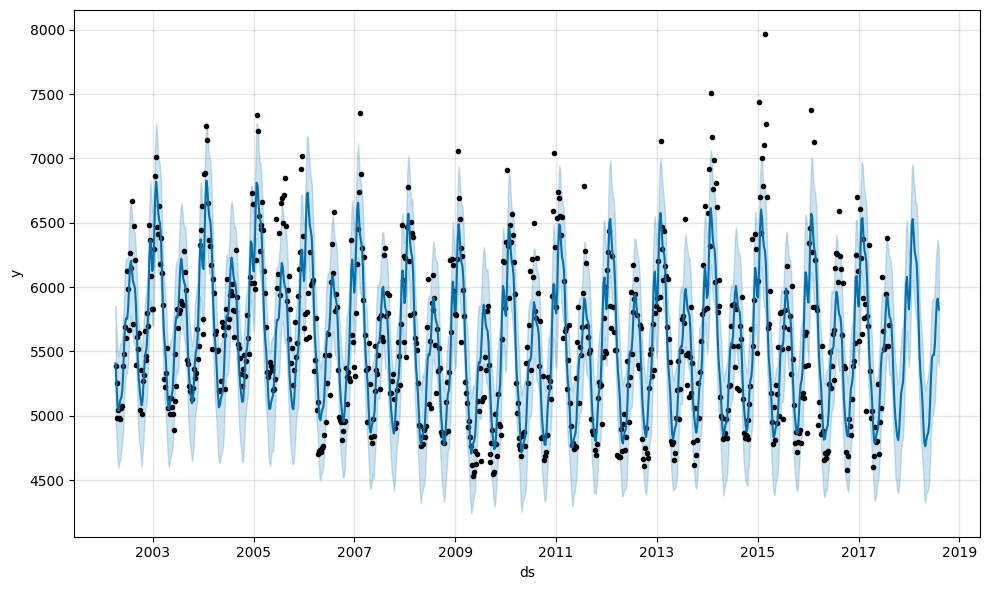

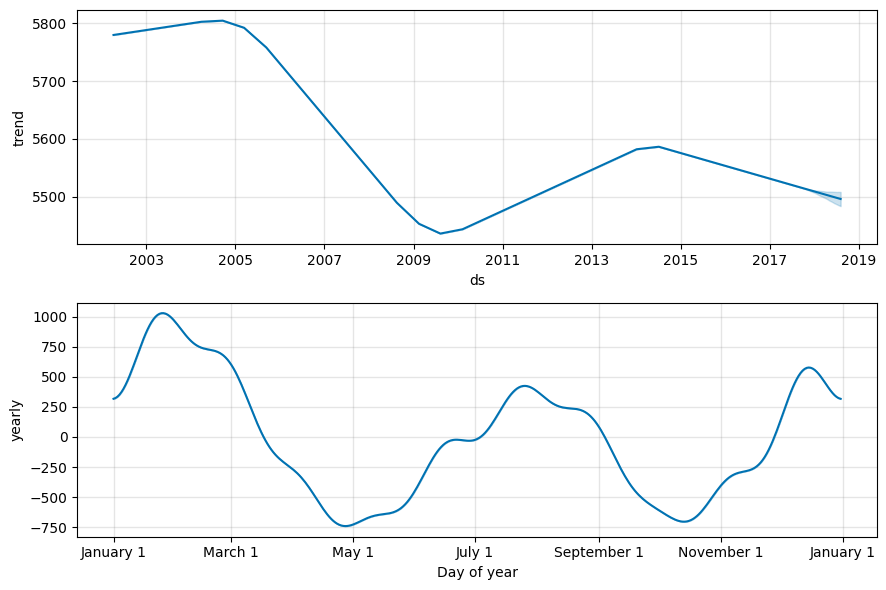

In [23]:
from prophet import Prophet
p_train = train.reset_index(); p_train.columns = ["ds", "y"]

m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(p_train)
future = m.make_future_dataframe(periods=52, freq="W")
fc = m.predict(future)
pred = fc.set_index("ds")["yhat"][-52:]

print("Prophet:", scores(test.values, pred.values))
m.plot(fc); m.plot_components(fc); plt.show()

In [33]:
# Format for Prophet
prophet_train = train_w.reset_index().rename(columns={'Datetime': 'ds', 'PJMW_MW': 'y'})
prophet_test = test_w.reset_index().rename(columns={'Datetime': 'ds', 'PJMW_MW': 'y'})

# Fit Prophet Model
m_prophet = Prophet(
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    yearly_seasonality=True,
    weekly_seasonality=False
)
m_prophet.fit(prophet_train)

# Forecast 52 weeks ahead
future = m_prophet.make_future_dataframe(periods=52, freq='W')
forecast = m_prophet.predict(future)

test_w['Prophet'] = forecast.tail(52)['yhat'].values

mae_prophet = mean_absolute_error(test_w['PJMW_MW'], test_w['Prophet'])
rmse_prophet = np.sqrt(mean_squared_error(test_w['PJMW_MW'], test_w['Prophet']))

print(f"--- Prophet Performance ---")
print(f"Prophet MAE:  {mae_prophet:.2f} MW")
print(f"Prophet RMSE: {rmse_prophet:.2f} MW\n")

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


--- Prophet Performance ---
Prophet MAE:  383.34 MW
Prophet RMSE: 525.08 MW



**Key Takeaways**
1. Impact of *changepoint_prior_scale:*

0.01 (Underfitting risk): Too rigid; fails to adapt to multi-year macroeconomic shifts or subtle trend turns.

0.5 (Overfitting risk): Overreacts to anomalous load swings (like weather extremes or telemetry outages), fitting noise rather than core load dynamics.

2. Impact of *seasonality_mode="multiplicative":*

Multiplicative seasonality assumes seasonal fluctuations scale proportionally with overall baseline demand (e.g., peak summer AC load creates larger percentage swings on hotter years).

3. Beating the Baseline:

High *seasonality_prior_scale* values (e.g., 10.0) give the model enough flexibility to fit strong seasonal/hourly swings. If Seasonal Naïve still wins, it highlights Prophet's difficulty in matching complex phase-shifted calendar rhythms (like moving holidays or exact 52-week day-of-week alignments) without extra regressors.

**Experiment: Option A: Alternative Model**
Try seasonality_mode="multiplicative", changepoint_prior_scale in [0.01, 0.05, 0.5], and seasonality_prior_scale. Put the results in a small table comparing MAE and RMSE against the baseline.

In [25]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prepare 'train' and 'test' for Prophet by converting Series to DataFrame with 'ds' and 'y' columns
p_train = train.reset_index()
p_train.columns = ["ds", "y"]

p_test = test.reset_index()
p_test.columns = ["ds", "y"]

# Baseline: Simple Seasonal Naive (using 'snaive' from previous cell)
# 'snaive' is already aligned with 'test' for weekly predictions
baseline_mae = mean_absolute_error(test.values, snaive.values)
baseline_rmse = np.sqrt(mean_squared_error(test.values, snaive.values))

# Hyperparameter grid configuration
changepoint_prior_scales = [0.01, 0.05, 0.5]
seasonality_prior_scales = [0.01, 0.1, 10.0]  # Standard evaluation grid
seasonality_mode = "multiplicative"

results = []

# Include baseline in results
results.append({
    "Model": "Baseline (Seasonal Naïve)",
    "changepoint_prior_scale": "N/A",
    "seasonality_prior_scale": "N/A",
    "MAE": round(baseline_mae, 2),
    "RMSE": round(baseline_rmse, 2)
})

# Grid Search Loop
for cps in changepoint_prior_scales:
    for sps in seasonality_prior_scales:
        model = Prophet(
            seasonality_mode=seasonality_mode,
            changepoint_prior_scale=cps,
            seasonality_prior_scale=sps,
            yearly_seasonality=True,
            weekly_seasonality=False, # Set to False for weekly-resampled data
            daily_seasonality=False   # Set to False for weekly-resampled data
        )
        model.fit(p_train)

        # Use 'W' frequency for weekly data
        future = model.make_future_dataframe(periods=len(p_test), freq='W')
        forecast = model.predict(future).tail(len(p_test))

        mae = mean_absolute_error(p_test['y'].values, forecast['yhat'].values)
        rmse = np.sqrt(mean_squared_error(p_test['y'].values, forecast['yhat'].values))

        results.append({
            "Model": f"Prophet (multiplicative)",
            "changepoint_prior_scale": cps,
            "seasonality_prior_scale": sps,
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2)
        })

# Display Results
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                    Model changepoint_prior_scale seasonality_prior_scale    MAE   RMSE
Baseline (Seasonal Naïve)                     N/A                     N/A 425.42 572.17
 Prophet (multiplicative)                    0.01                    0.01 358.41 502.95
 Prophet (multiplicative)                    0.01                     0.1 366.84 504.14
 Prophet (multiplicative)                    0.01                    10.0 369.75 507.89
 Prophet (multiplicative)                    0.05                    0.01 372.70 520.24
 Prophet (multiplicative)                    0.05                     0.1 381.62 522.94
 Prophet (multiplicative)                    0.05                    10.0 383.34 525.08
 Prophet (multiplicative)                     0.5                    0.01 415.10 565.57
 Prophet (multiplicative)                     0.5                     0.1 423.02 569.49
 Prophet (multiplicative)                     0.5                    10.0 422.64 569.04


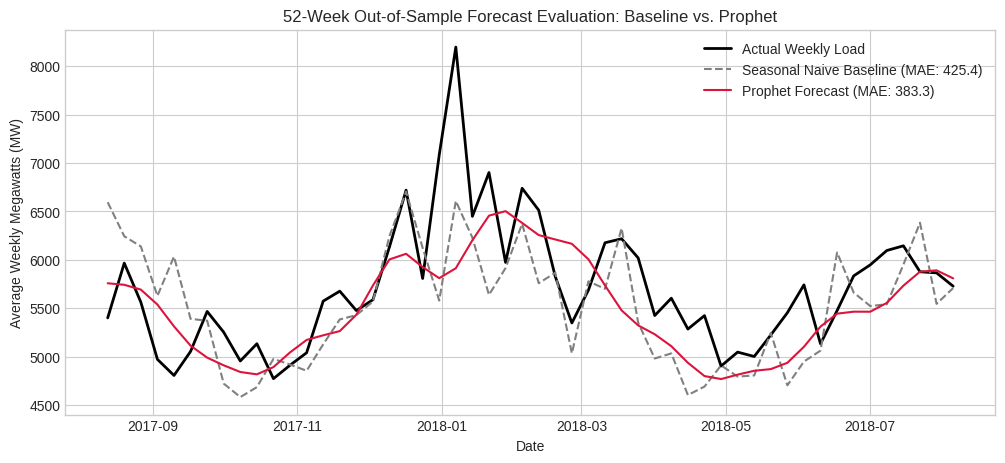

                    Model  MAE (MW)  RMSE (MW)
Baseline (Seasonal Naïve)    425.42     572.17
 Prophet (Multiplicative)    383.34     525.08


In [34]:
plt.figure(figsize=(12, 5))
plt.plot(test_w.index, test_w['PJMW_MW'], label='Actual Weekly Load', color='black', linewidth=2)
plt.plot(test_w.index, test_w['Baseline_SNaive'], label=f'Seasonal Naive Baseline (MAE: {mae_base:.1f})', linestyle='--', color='gray')
plt.plot(test_w.index, test_w['Prophet'], label=f'Prophet Forecast (MAE: {mae_prophet:.1f})', color='crimson')

plt.title('52-Week Out-of-Sample Forecast Evaluation: Baseline vs. Prophet')
plt.xlabel('Date')
plt.ylabel('Average Weekly Megawatts (MW)')
plt.legend()
plt.grid(True)
plt.show()

# Final Comparative Summary Table
results_df = pd.DataFrame([
    {'Model': 'Baseline (Seasonal Naïve)', 'MAE (MW)': round(mae_base, 2), 'RMSE (MW)': round(rmse_base, 2)},
    {'Model': 'Prophet (Multiplicative)', 'MAE (MW)': round(mae_prophet, 2), 'RMSE (MW)': round(rmse_prophet, 2)}
])
print(results_df.to_string(index=False))

**Exercise 6 (BONUS - Option A): Model Comparison & AECO Conclusion**

**AECO Real-World Reliability Assessment**: Weekly aggregated forecasts are effective for high-level facility management decisions like annual budget forecasting, seasonal energy procurement, and major HVAC overhaul planning. However, because weekly averages mask intra-day peak loads and sharp daily temperature spikes, this forecast is not reliable enough on its own for real-time building automation, demand response management, or daily equipment scheduling.